# Lab 2 — Digital Image Fundamentals
**Course:** ARTI407 – Image Processing  
**College of Computer Science and Information Technology**  
**Imam Abdulrahman Bin Faisal University**

This notebook covers the lab manual:
1. **Sampling and Quantization**
2. **Arithmetic Operations** (add, subtract, add constant)
3. **Set / Logical Operations** (union, intersection, difference, symmetric difference)
4. **Practical Tasks**

> **Note on images:** The lab references `lena_gray_256.tif`, `cameraman.tif`, `A.png`, `B.png`. Since those files aren't bundled with the notebook, this notebook uses built-in `skimage` images so every cell runs out of the box. To use your own image, just replace the loading line.

## Setup

In [1]:
import cv2
import numpy as np
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt

%matplotlib inline

---
## Section 1 — Image Sampling and Quantization

- **Sampling** = how many pixels we keep (spatial resolution).
- **Quantization** = how many gray levels we keep (intensity resolution).

In [2]:
def sample_image(image, factor):
    """Downsamples the image by the given factor."""
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    """Reduces the number of grayscale levels in the image."""
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1), plt.imshow(original, cmap='gray')
    plt.title('Original Image'), plt.axis('off')
    plt.subplot(1, 3, 2), plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image'), plt.axis('off')
    plt.subplot(1, 3, 3), plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image'), plt.axis('off')
    plt.show()

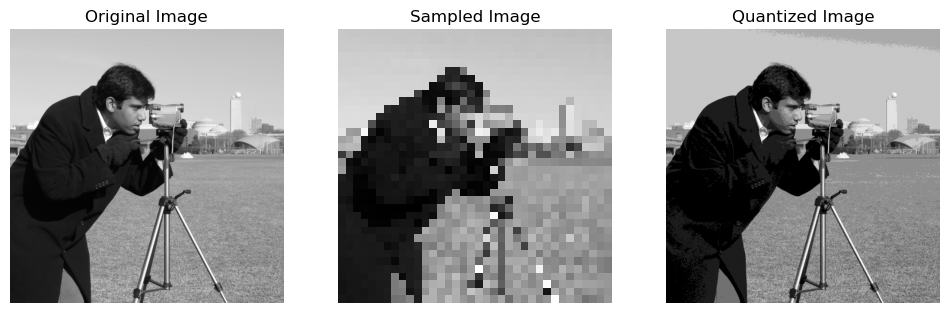

In [3]:
original_image = data.camera()

sampling_factor = 14
quantization_levels = 9

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

---
## Section 2 — Arithmetic Operations

Add two images by converting them to numpy arrays and adding element-wise.

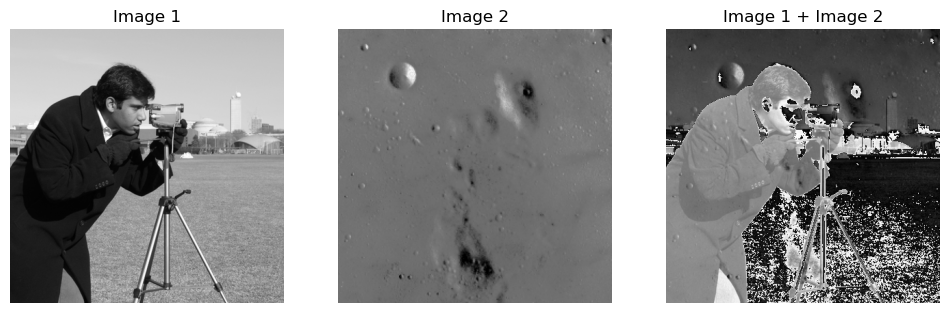

In [4]:
img1 = Image.fromarray(data.camera())
img2 = Image.fromarray(data.moon())

new_size = (400, 400)
img1 = img1.resize(new_size, Image.Resampling.LANCZOS)
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = im1arr + im2arr
result_image = Image.fromarray(addition)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 1 + Image 2'), plt.axis('off')
plt.show()

---
## Section 3 — Set / Logical Operations

Pixel-wise bitwise operations on two images. Lab demo: **union (OR)**.

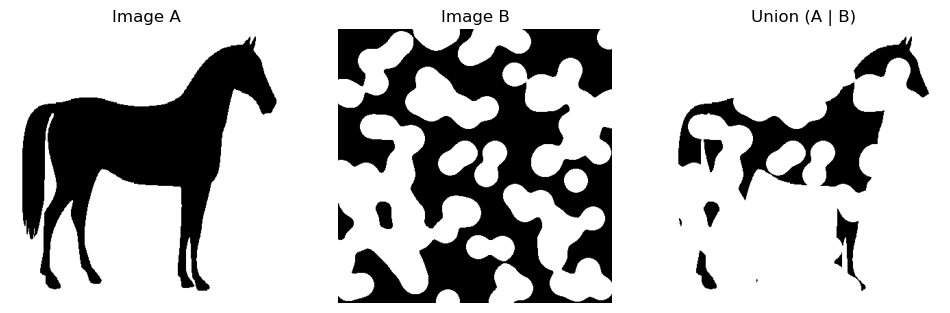

In [5]:
img3 = Image.fromarray(data.horse())
img4 = Image.fromarray(data.binary_blobs(length=400))

img3 = img3.resize(new_size, Image.Resampling.LANCZOS)
img4 = img4.resize(new_size, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
result_image_2 = Image.fromarray(union)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img3, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img4, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_2, cmap='gray'), plt.title('Union (A | B)'), plt.axis('off')
plt.show()

---
# Practical Tasks

## Task 1 — Change sampling and quantization parameters and observe the effects

Try multiple values of the sampling factor and the number of quantization levels to see how each affects the image.

In [6]:
def load_image(name):
    func = getattr(data, name)  
    return func()

### 1a) Effect of sampling factor (spatial resolution)

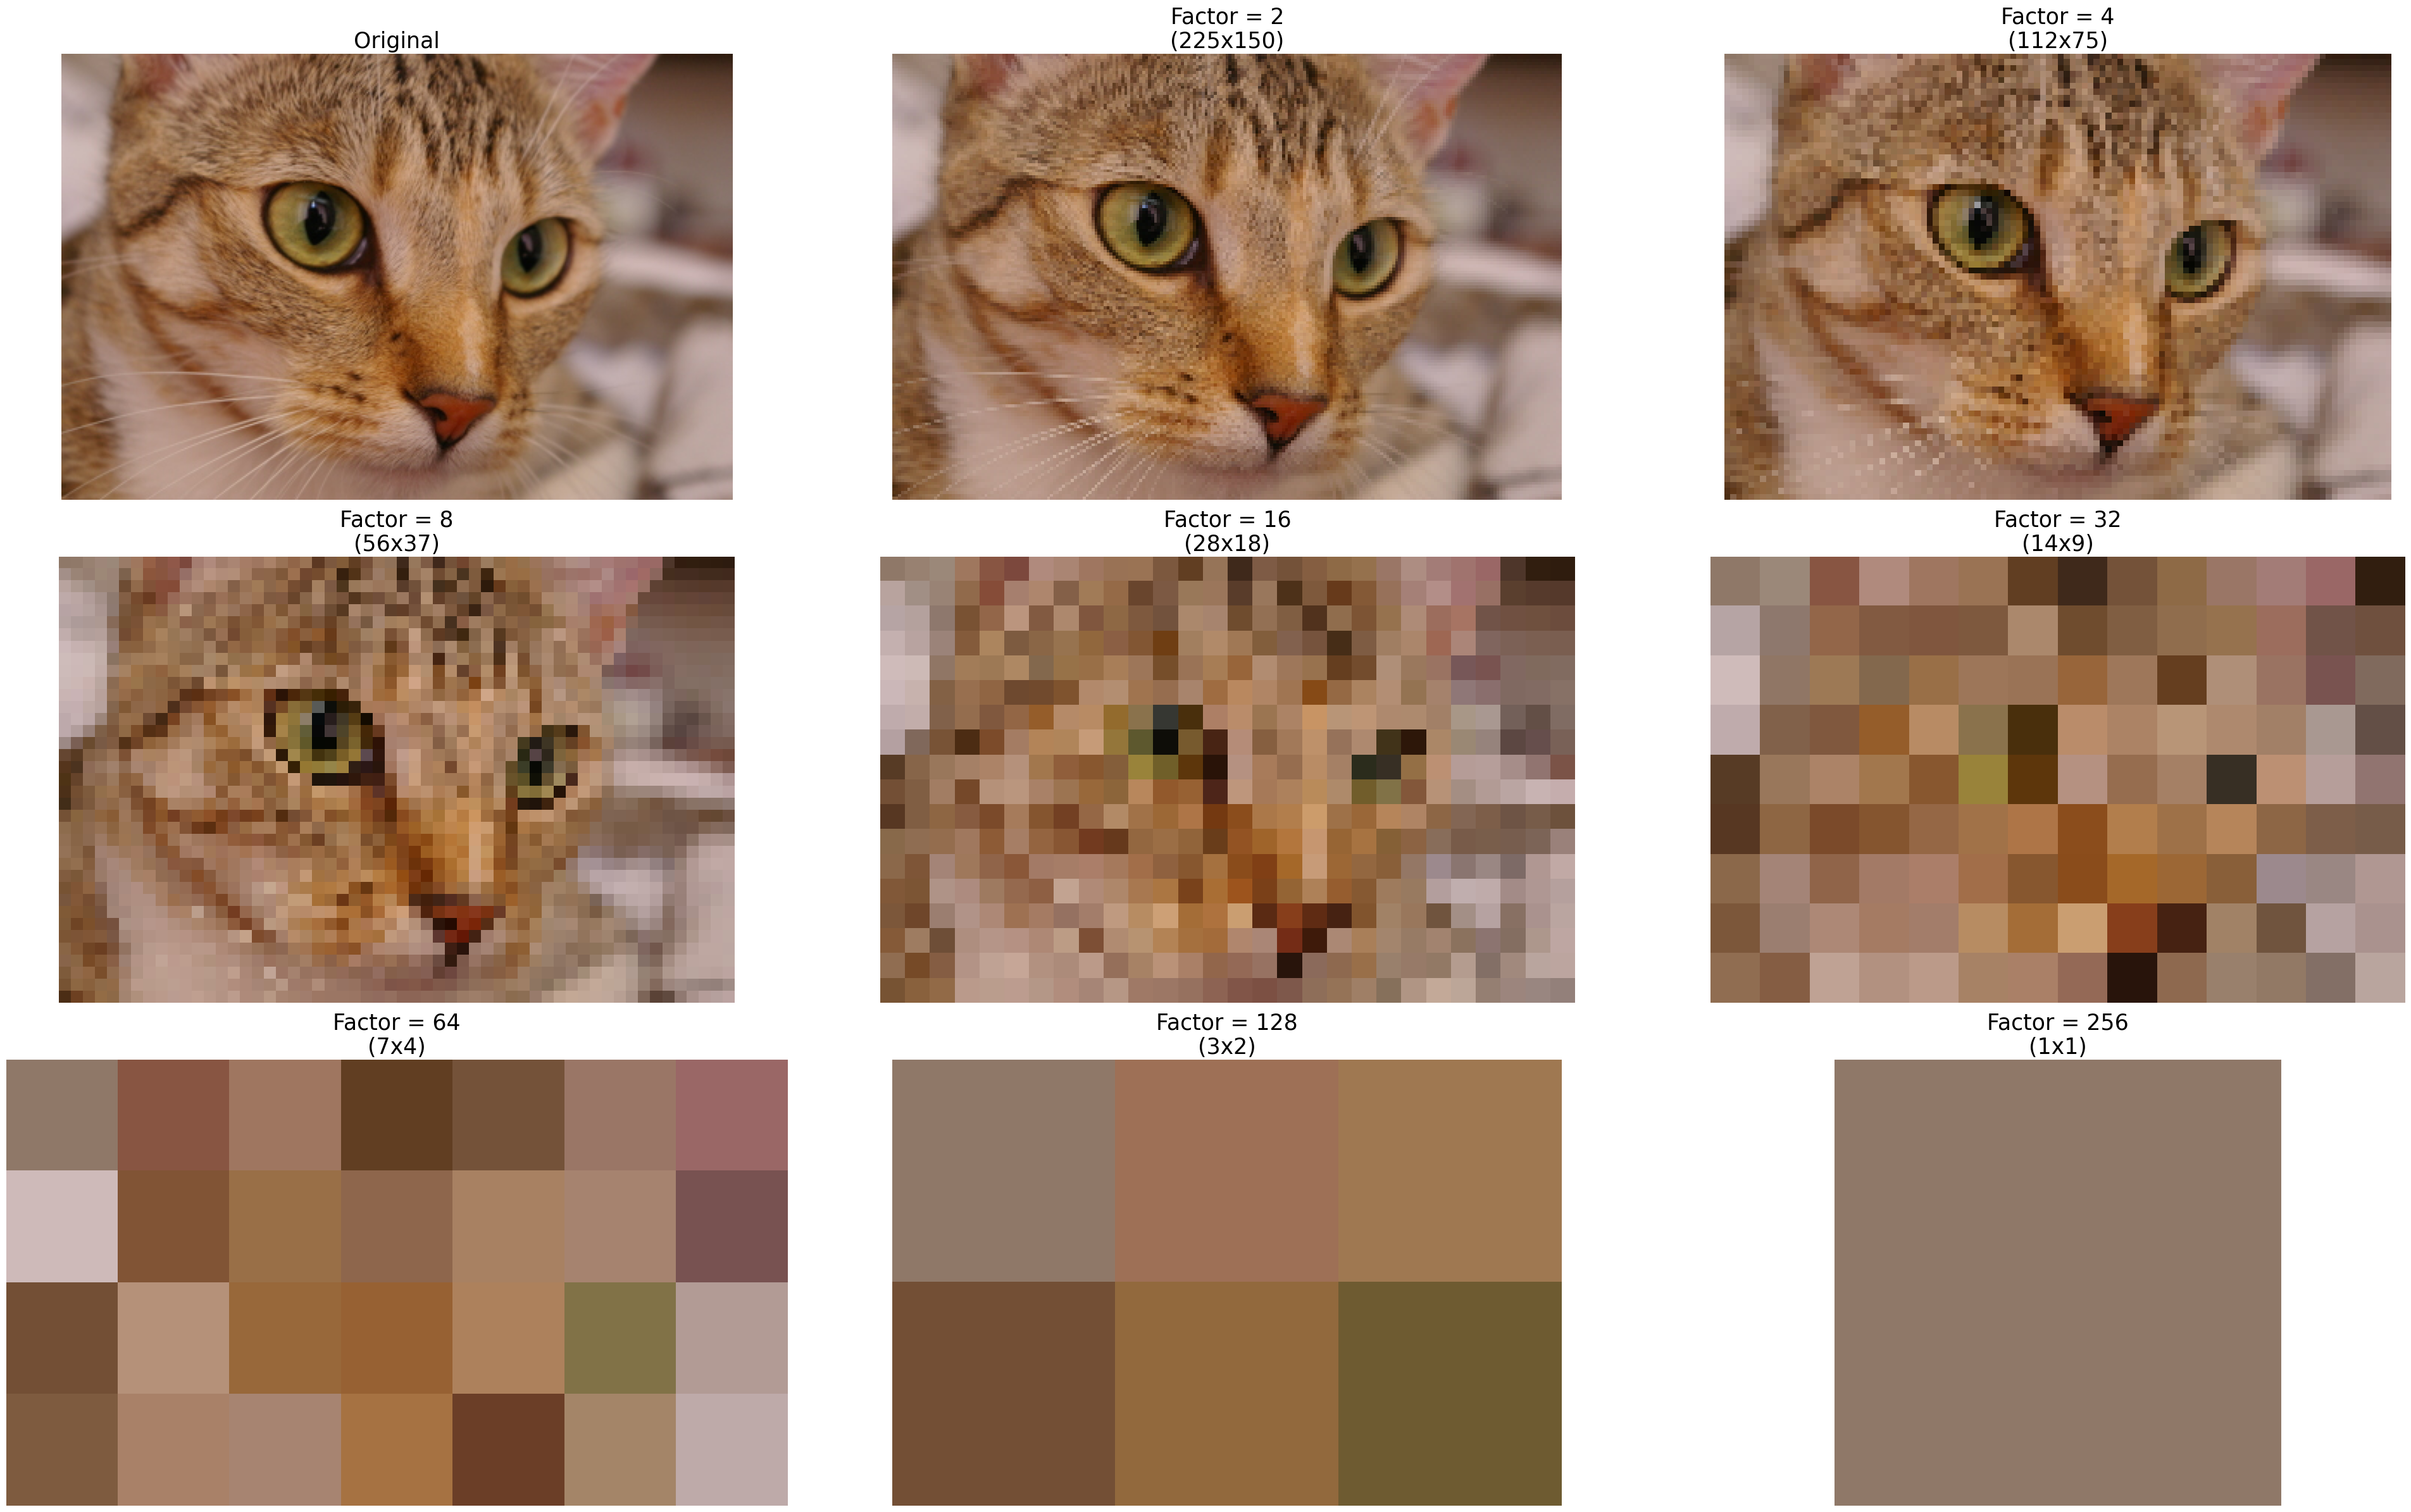

In [7]:
factors = [2,4,8,16,32,64,128,256]
img_cat = load_image('cat')
plt.figure(figsize=(40,24))
plt.subplot(3, 3, 1)
plt.imshow(img_cat, cmap='gray')
plt.title('Original', fontsize=25)
plt.axis('off')

for i, factor in enumerate(factors, start=2):
    sampled = sample_image(img_cat, factor)
    plt.subplot(3, 3, i)
    plt.imshow(sampled, cmap='gray')
    plt.title(f'Factor = {factor}\n({sampled.shape[1]}x{sampled.shape[0]})', fontsize=25)
    plt.axis('off')

plt.tight_layout()
plt.show()

### 1b) Effect of quantization levels (intensity resolution)

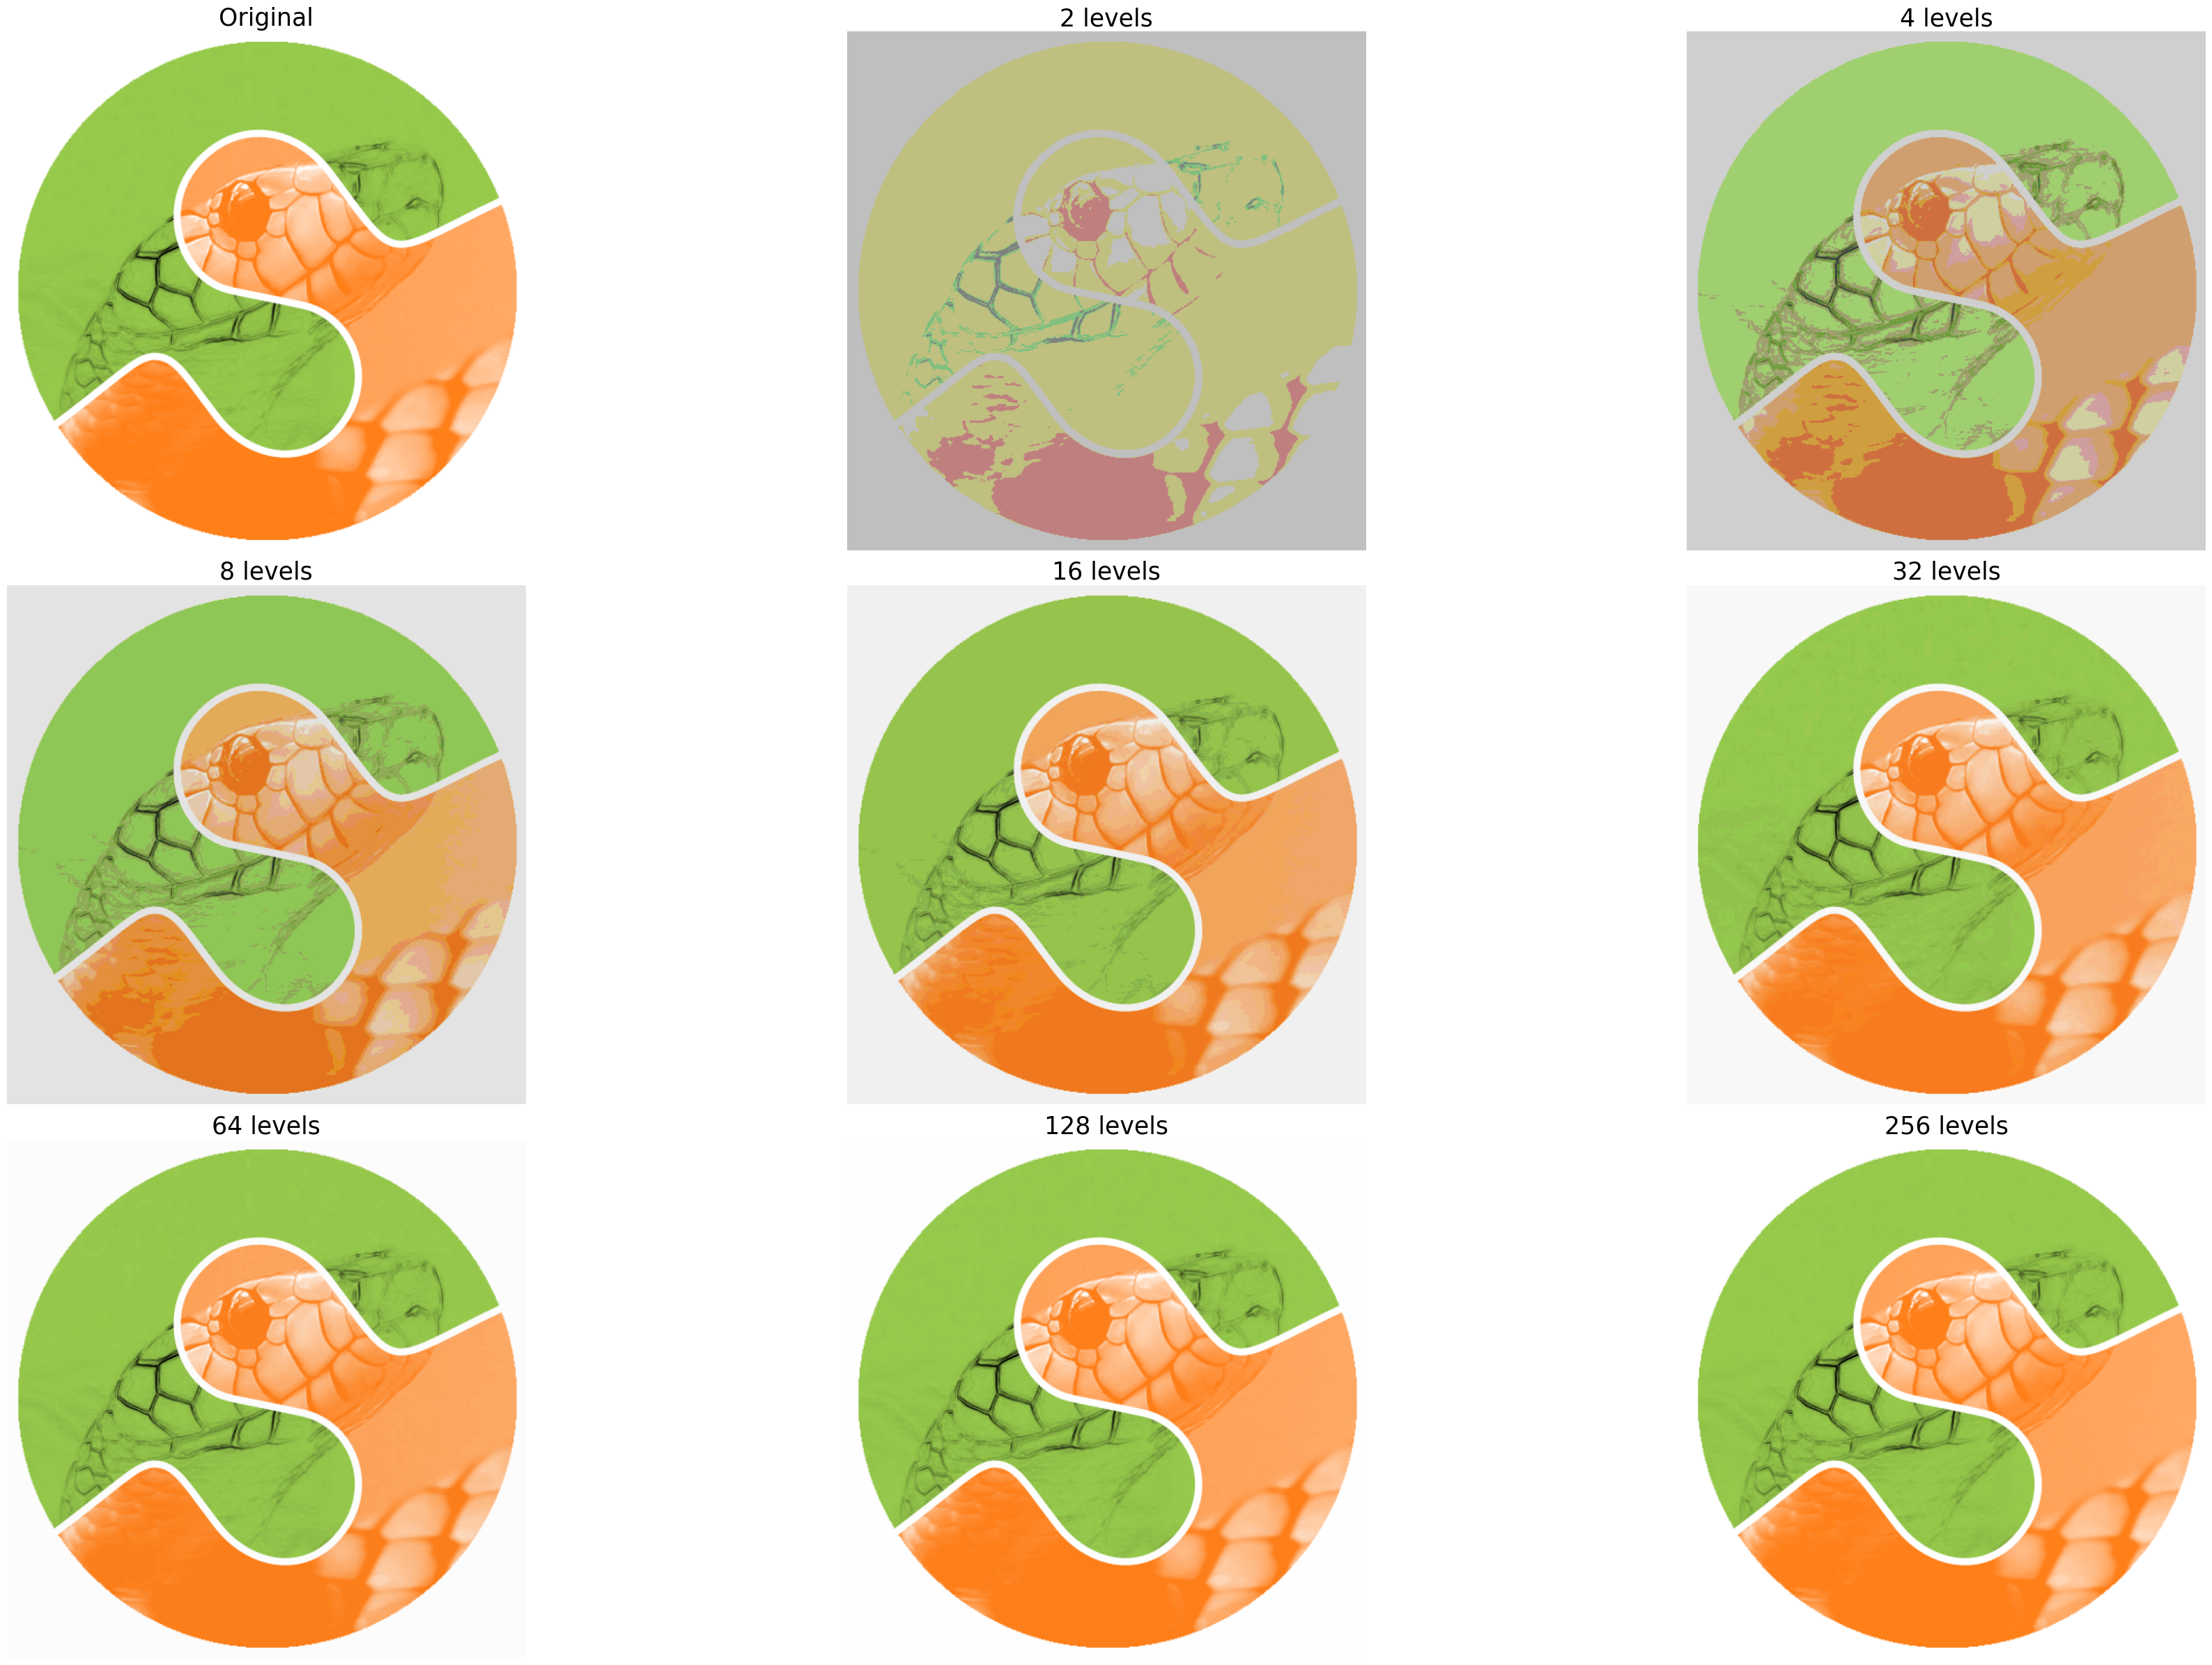

In [8]:
levels = [2,4,8,16,32,64,128,256]
img_logo = load_image('logo')

plt.figure(figsize=(40,24))
plt.subplot(3, 3, 1)
plt.imshow(img_logo)
plt.title('Original', fontsize=25)
plt.axis('off')

for i, level in enumerate(levels, start=2):
    quantized = quantize_image(img_logo, level)
    plt.subplot(3, 3, i)
    plt.imshow(quantized)
    plt.title(f'{level} levels', fontsize=25)
    plt.axis('off')

plt.tight_layout()
plt.show()

---
## Task 2 — Image Arithmetic and Set Operations

Required operations:
1. Subtract two images and display the result
2. Add one image with a constant value 175
3. Set difference on two grayscale images
4. Symmetric difference on two grayscale images
5. Intersection on two grayscale images

### 2a) Subtract two images

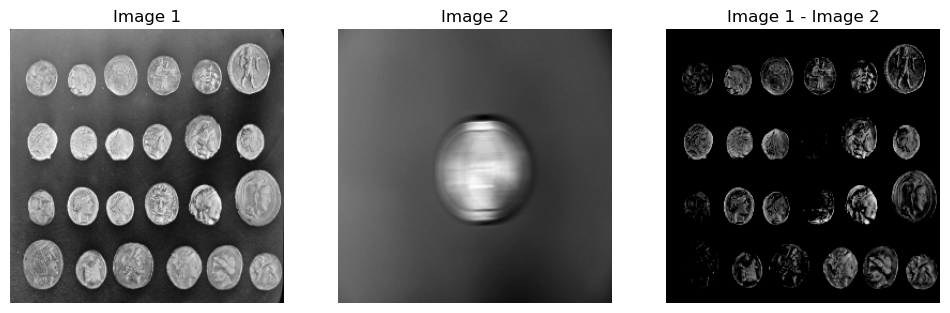

In [9]:
img_coins = load_image('coins')
img_clock = load_image('clock')
if img_coins.ndim == 3:
    img_coins = cv2.cvtColor(img_coins, cv2.COLOR_BGR2GRAY)
if img_clock.ndim == 3:
    img_clock = cv2.cvtColor(img_clock, cv2.COLOR_BGR2GRAY)
target_size = (256, 256)
img_coins = cv2.resize(img_coins, target_size)
img_clock = cv2.resize(img_clock, target_size)

subtraction = cv2.subtract(img_coins, img_clock)
result_image_sub = Image.fromarray(subtraction)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img_coins, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img_clock, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_sub, cmap='gray'), plt.title('Image 1 - Image 2'), plt.axis('off')
plt.show()

### 2b) Add image with constant value 175

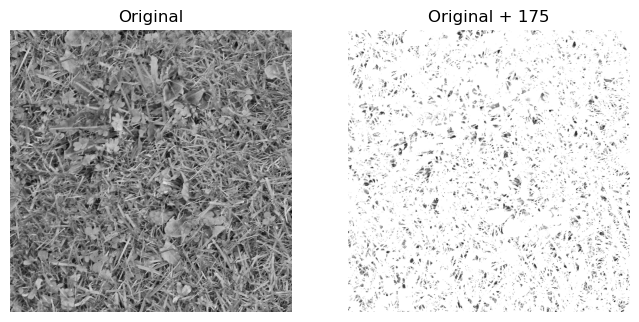

In [11]:
img_grass = load_image('grass') 
if img_grass.ndim == 3:
    img_grass = cv2.cvtColor(img_grass, cv2.COLOR_BGR2GRAY)

constant_value = 175
constant_arr = np.full(img_grass.shape, constant_value, dtype=np.uint8)
added_constant = cv2.add(img_grass, constant_arr)
result_image_const = Image.fromarray(added_constant)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1), plt.imshow(img_grass, cmap='gray'), plt.title('Original'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(result_image_const, cmap='gray'), plt.title(f'Original + {constant_value}'), plt.axis('off')
plt.show()

### 2c-2e) Set operations on grayscale images

| Operation | Bitwise formula | Meaning |
|---|---|---|
| **Intersection** | `A & B` | bits set in both |
| **Set difference** | `A & ~B` (A − B) | bits in A but not in B |
| **Symmetric difference** | `A ^ B` | bits in A or B but not both |
| **Union** (extra) | `A \| B` | bits in either |

In [ ]:
img_astro = load_image('astronaut')
img_rocket = load_image('rocket')
if img_astro.ndim == 3:
    img_astro = cv2.cvtColor(img_astro, cv2.COLOR_BGR2GRAY)
if img_rocket.ndim == 3:
    img_rocket = cv2.cvtColor(img_rocket, cv2.COLOR_BGR2GRAY)
target_size = (256, 256)
img_astro = cv2.resize(img_astro, target_size)
img_rocket = cv2.resize(img_rocket, target_size)

intersection = img_astro & img_rocket
set_difference = img_astro & ~img_rocket
symmetric_difference = img_astro ^ img_rocket
union = img_astro | img_rocket

result_intersection = Image.fromarray(intersection)
result_set_diff = Image.fromarray(set_difference)
result_sym_diff = Image.fromarray(symmetric_difference)
result_union = Image.fromarray(union)

plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 2), plt.imshow(img_astro, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 4, 3), plt.imshow(img_rocket, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.show()

plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1), plt.imshow(result_intersection, cmap='gray'), plt.title('Intersection (A & B)'), plt.axis('off')
plt.subplot(1, 4, 2), plt.imshow(result_set_diff, cmap='gray'), plt.title('Set Difference (A & ~B)'), plt.axis('off')
plt.subplot(1, 4, 3), plt.imshow(result_sym_diff, cmap='gray'), plt.title('Symmetric Difference (A ^ B)'), plt.axis('off')
plt.subplot(1, 4, 4), plt.imshow(result_union, cmap='gray'), plt.title('Union (A | B)'), plt.axis('off')
plt.tight_layout()
plt.show()